In [185]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import PairwiseComparison as pc
import pandas as pd
import seaborn as sns

# Modularity in College Football
John S. McAlister - *Princeton University*<br>
Jack Haight - *University of Tennessee - Knoxville*<br>
Mate Szurop - *University of Tennessee - Chattenooga*<br>
<br><br>

The landscape of college football has always been very modular because teams play frequently within their conferences and rarely outside of their conferences. This modularity poses a problem when it comes time to rank teams. The sparsity of interconference information means that analysts who publish rankings have little data to use when comparing teams in different conferences that have not played one another. Because this is a source of great friction for fans of college football, we seek to quantify the effect that modularity has on the college football landscape.

## Introduction
The landscape of college football has always been very modular because teams play frequently within their conferences and rarely outside of their conferences. This modularity poses a problem when it comes time to rank teams. The sparsity of interconference information means that analysts who publish rankings have little data to use when comparing teams in different conferences that have not played one another. Because this is a source of great friction for fans of college football, we seek to quantify the effect that modularity has on the college football landscape. Before we begin with our analysis we introduce out two models for ranking. The history independent Zermelo's algorithm and the history dependent Elo algorithm. Both have been commonly used to produce ranking from pairwise comparison data and, at first sight, they appeat to be very similar. However, there are crucial differences which mean that they behave differentl in a modular setting. 

### Zermelo
Zermelo's algorithm is a history independent method to turn pairwise comparison data into an estimation of strengths. Every individual $i$ is said to have some strength $s_i$ and when players $i$ and $j$ interact, player $i$ wins with a probability $p_{i,j}=f(s_i-s_j)$. Using the standard logistic function $f(x)=(1+e^{-x})^{-1}$, we see see that it is easier to keep track of player's power $\pi_i=e^{s_i}$. Zermelos algorithm takes win-loss data from a strongly connected digraph and efficiently approximates the the power vector $\pi$ which maximizes the likelihood of recovering the win-loss data. The maximum likelihood estimator always exists and is unique so the initial guess for $\pi$ has no impact, although constant initial $\pi$ may result in issues fin the numerical methods. 

### Elo
The Elo method is a history dependent method to turn pairwise comparison data into an estimation of strengths. It has a similar structure to the Zermelo model but it take sthe history into account. Each player $i$ has a rating $\theta_i$ and the probability that player $i$ beat player $j$ is, again, modeled as $p_{i,j}=(1+e^{-c(\theta_i-\theta_j)})^{-1}$. The difference is that, after each game, every player's rating is updated in the following way, $\theta_i'=\theta_i+K(S_{i,j}-p_{i,j})$ where $K$ is some constant and $S_{i,j}$ is 1 if $i$ beat $j$ , 0 if $j$ beat $i$ and $1/2$ in the case of a draw. There are other more complicated features of the Elo model but the general idea is that after each match, each team's Elo is updated and thus the results are history dependent. The same match results, in a different order, may result in different Elo ratings. Moreover, for any finite time horizon, the initial guess has some impact on the result. 

## Methods

In our investigation, we use two ranking methods mentioned above, and we investigate both in two different ways. Using data from the past 10 years of college football, we fit each model to the data to find a ranking and an estimation of strength for each team in FBS.

In order to be able to run numerical experiments to test our hypotheses, we also generate synthetic data in an imaginary football league with only two sparsely connected conferences. Between the real data and synthetic data, we (a) directly measure the change in ranking accuracy as a function of modularity, (b) perform pseudo-empirical hypothesis tests to test the validity of claims comparing the SEC and the Big 10, and (c) examine how the sensitivity with respect to initial data of the history-dependent method changes with respect to modularity. 

In order to investigate this we use synthetic data from an imagined league with two conferences of sizes $n$ and $m$. We assume that each team has a true power score which is treated as the base truth for a simulation. We consider how well the model can recover this base truth. A random schedule is generated with $g$ conference games and $M$ total non-conference games so each team will play at least $g$ games and some will play more if they are chosed to play a non-conference game. Each matchup results in a score which is determined by the difference in power between the two teams.

As an example, consider the league with the 10 team conference $A$ and the 12 team conference $B$. Each team plays a 9 game conference schedule and there are a total of 10 interconference games. The simulate() function simulates the season and generates list of scores along with the true power of each team. 

In [186]:
result = pc.simulate(10,12,10,dist = 'exp')
W=result[0]
p=result[1]
print("Results matrix")
print(W)
print("True power")
print(p)

Results matrix
[[ 0  4  6 17  7  9  2 39  4  3  0  0 16  0  0  0  0  0  0  3  3  0]
 [37  0 40 33 39 33 35 72 40 12  0  0  0  0  0  0  0  0  0  0  0  0]
 [36 18  0 51 15 29 17 61 24 13  0  0  0  0  0  0  0  0  0 13  0  0]
 [42  7 27  0  9 24  5 33  4  9  0  0  0  0  0  0  0  0  0  0  0  0]
 [55 32 28 55  0 31 19 67 33  8  0  0  0  0  0 28  0  0  0  0 11  0]
 [40 10 11 49 17  0 12 36 13  9  0  0  0  0  0  0  0  0  0  0  0  0]
 [69 38 45 57 32 44  0 62 35 22  0 28 33  0  0  0  0  0  0  0  0  0]
 [26  2  4  4  5  2  3  0  1  0  0  0  0  0  0  0  0  0  5  0  0  0]
 [40 42 50 19 51 29 26 94  0 32  0  0  0  0  0 18  0  0  0  0  0  0]
 [56 25 53 63 23 40 24 78 37  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 34 27 51 32  0 51 28 39 23  0 42]
 [ 0  0  0  0  0  0 17  0  0  0  5  0 32 39 36 18  0 20 31 28 16  0]
 [79  0  0  0  0  0  8  0  0  0  6 20  0 32 13 12  8  0 10  0 13 32]
 [ 0  0  0  0  0  0  0  0  0  0  7 19 22  0 10  0 14  0 11 10 10 25]
 [ 0  0  0  0  0  0

We know each teams true power and so we know the objective correct ranking. We write it in the following way so if there is a $i$ in index $j$ in the array, team $j$ is ranked $i+1$ st. So if there is a 3 at index 0, team 0 is ranked 4th. If there is a 15 at index 8, team 8 is ranked 16th.   

In [187]:
r = np.argsort(np.flip(np.argsort(p)))
print(r)

[20  8 15 19 12 17  6 21 10  3  1 11 16 18  7  4  9  0 13  5  2 14]


Now we can try to recover the tru ranking and the true power using the simulated game information and our ranking methods. For the history independent method, we simply find the maximumu likelihood unbiased estimators for the data using the method described by Newman

In [188]:
rZer = pc.RankZermelo(W)
rZer = np.argsort(np.flip(rZer))
print(rZer)

[20  9 15 19 11 17  6 21  8  3  1 12 16 18  7  4 10  0 13  5  2 14]


We see that the two are close but not exact in most cases. We measure the distance between the true ranking and the found ranking in several ways. Mostly simply we find the $\ell^1$ distance between the two vectors. We also want to evaluate the quality of the rankings by determining if they would correctly seed a playoff with $x$ number of teams

In [189]:
print("l1 distance?")
print(pc.L1dist(r,rZer))
print("Correct Chamption?")
print(pc.correct_winner(r,rZer))
print("Correctly seeded 4 team playoff?")
print(pc.correct_top_four(r,rZer))
print("Correctly Seeded 12 team playoff?")
print(pc.correct_top_12(r,rZer))

l1 distance?
0.2727272727272727
Correct Chamption?
True
Correctly seeded 4 team playoff?
True
Correctly Seeded 12 team playoff?
False


The same can be done with the Elo model but, because it is history dependent, it requires an initial condition. In general, the closer that our initial condition is to the reality, the better our final prediciton. Because the models are closely related to each other, we can convert between power and ELO rather directly. $\theta_i=\ln (\pi_i)+1500$ where $1500$ is chosen as the average ELO rating among all teams. To control the quality of our guess we let our initial guess be generated by $$\theta_0=\alpha(\frac{1}{c}\ln(\pi)+1500)+(1-\alpha)(\mathcal{N}(1500,\sigma))$$ so that $\alpha$ controls how close our prediction is to the true ELO and $\sigma$ controls the amount of variability in our error. Higher $\alpha$ and lower $\sigma$ improve the quality of the intial guess but $\sigma=0$ is not sufficient for a perfect guess. When $\sigma=0$, the parameter $\alpha$ takes on the same meaning as $\rho$ (a regression parameter included in the parameter estimates).  
We will demonstrate with both a high quality initial guess ($\alpha = 0.75, \sigma = 20$) and a low quality initial guess ($\alpha = 0.5,\sigma = 200$).

In [190]:
initialG=0.75*(np.log(p)*100+1500)+(0.25*np.random.normal(1500,20,[22]))
print(initialG)
initialB=0.5*(np.log(p)*100+1500)+(0.5*np.random.normal(1500,200,[22]))
print(initialB)

[1231.12463408 1437.71127925 1372.69498301 1304.6523205  1405.89422319
 1359.44932021 1454.81547918 1170.42099559 1434.17761697 1468.30376581
 1497.44718703 1419.34191158 1365.30094065 1318.42713308 1455.68155943
 1471.94041579 1434.05916566 1497.36750628 1413.83654105 1459.73211756
 1488.10463227 1388.80655525]
[1455.98838448 1590.2803859  1336.53506739 1213.01237834 1507.35405168
 1470.38487995 1587.10460088 1364.10331629 1377.44931139 1505.02561908
 1363.70376879 1507.13896298 1565.65792941 1400.84901346 1547.08179259
 1715.74790316 1516.15477634 1411.65498089 1466.77814559 1520.62229945
 1474.2001604  1530.72570054]


In [191]:
EloG=pc.RankELO(W,initialG)
rELOg = np.argsort(np.flip(EloG))
EloB=pc.RankELO(W,initialB)
rELOb = np.argsort(np.flip(EloB))
print("True Ranking")
print(r)
print("Good ELO ranking")
print(rELOg)
print("Bad ELO ranking")
print(rELOb)

True Ranking
[20  8 15 19 12 17  6 21 10  3  1 11 16 18  7  4  9  0 13  5  2 14]
Good ELO ranking
[20  9 14 18 11 15  3 21  7  2  1 12 17 19  8  5 10  0 13  6  4 16]
Bad ELO ranking
[20  7 14 18 10 16  4 21  9  1  3 11 17 19  8  0 12  2 13  6  5 15]


We can use the same measures of accuracy to evaluate these rankings. Each result is listed first for the good ranking then for the bad ranking.

In [192]:
print("l1 distance?")
print(pc.L1dist(r,rELOg))
print(pc.L1dist(r,rELOb))
print("Correct Chamption?")
print(pc.correct_winner(r,rELOg))
print(pc.correct_winner(r,rELOb))
print("Correctly seeded 4 team playoff?")
print(pc.correct_top_four(r,rELOg))
print(pc.correct_top_four(r,rELOb))
print("Correctly Seeded 12 team playoff?")
print(pc.correct_top_12(r,rELOg))
print(pc.correct_top_12(r,rELOb))

l1 distance?
1.0909090909090908
1.3636363636363635
Correct Chamption?
True
False
Correctly seeded 4 team playoff?
False
False
Correctly Seeded 12 team playoff?
False
False


## Results

### part A - Ranking Quality and Modularity
Using these methods we can evaluate the ways that ranking, both in the synthetic environment and in the real world, are impacted by high modularity. Our first simple experiment is to vary the number of interconference games from 1 to 10 to see how the accuracty of each ranking method changes.

In [ ]:
#dfZer=pc.scanZer(16,18,0,20,reps=2000,dist = "exp")
#dfELOGG = pc.scanELO(16,18,0,20,reps = 2000,dist = "exp",info = 0.9,spread = 20)
#dfELOGB = pc.scanELO(16,18,0,20,reps = 2000,dist = "exp",info = 0.5,spread = 20)
#dfELOBB = pc.scanELO(16,18,0,20,reps = 2000,dist = "exp",info = 0.5,spread = 200)

#dfZer.to_csv("DataFiles/dfZer2000.csv")
#dfELOGG.to_csv("DataFiles/dfELOGG2000.csv")
#dfELOGB.to_csv("DataFiles/dfELOGB2000.csv")
#dfELOBB.to_csv("DataFiles/dfELOBB2000.csv")


dfZer=pd.read_csv("DataFiles/dfZer2000.csv")
dfELOGG=pd.read_csv("DataFiles/dfELOGG2000.csv")
dfELOGB=pd.read_csv("DataFiles/dfELOGB2000.csv")
dfELOBB=pd.read_csv("DataFiles/dfELOBB2000.csv")

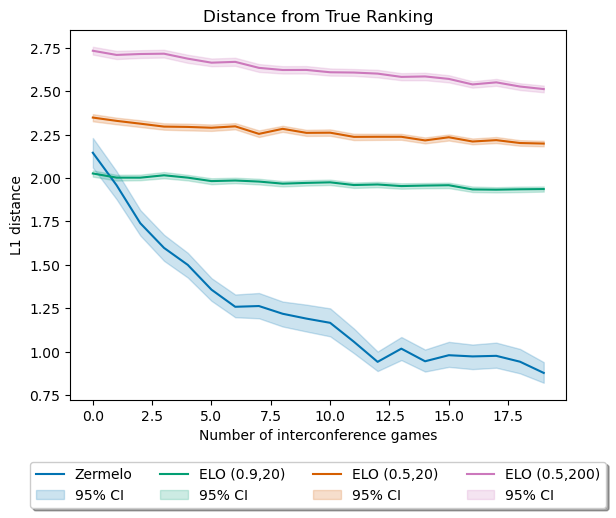

In [194]:
fig = plt.figure
ax = plt.subplot(111)
line1 = sns.lineplot(data=dfZer, x='M', y='LD')
line2 = sns.lineplot(data=dfELOGG, x='M', y='LD')
line3 = sns.lineplot(data=dfELOGB, x='M', y='LD')
line4 = sns.lineplot(data=dfELOBB, x='M', y='LD')
ax.set(xlabel='Number of interconference games', ylabel ='L1 distance', title = 'Distance from True Ranking')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=4,labels=["Zermelo","95% CI","ELO (0.9,20)","95% CI","ELO (0.5,20)","95% CI","ELO (0.5,200)","95% CI"])

In the reasonable region in which every team plays between 0 and 1 interconference game, there is a clear improvement in the quality of the Zermelo rankings but there is no clear improvement in the ELO rankings, even with high quality initial data. However, the quality of the intial data has a clear and significant impact. 

### Part B - Emperical Hypothesis Testing

Next we focus only on the Zermelo algorithm to attempt to evaluate claims about the quality of the two mega conferences, the Big 10 and the SEC. In order to do this we will develop an emperical distribution from synthetic data from which to test our hypothesis. We simply simulate many seasons and compute the difference between the average power or rank in conference A (with 16 teams) and conference B (with 18 teams). Then we estimate the power of each team with the Zermelo algorithm and measure this same difference in the found powers or ranks. This gives us a distribution of "conference bias errors." The distribution looks different depending on the amount of interconference games played

c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:40: RuntimeWarning: invalid value encountered in divide
  update_k = 90  # Elo update factor
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:41: RuntimeWarning: invalid value encountered in divide
  season = list()


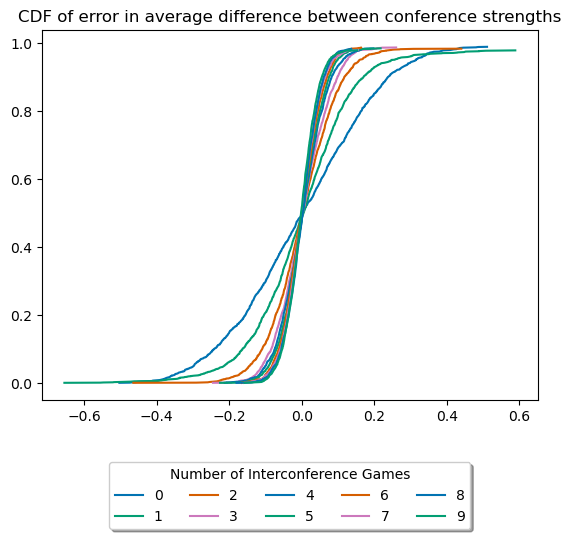

In [195]:
fig = plt.figure
ax = plt.subplot(111)
for i in range(0,10):
    d=pc.difDistribution(16,18,i,t=None,reps=2000,comp=True)
    [x,y]=pc.get_ecdf(d)
    plt.plot(x,y,label = i)
ax.set_title("CDF of error in average difference between conference strengths")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
         fancybox=True, shadow=True, ncol=5, title = "Number of Interconference Games")
plt.show()

we can get the same type of CDF for the difference in average rank

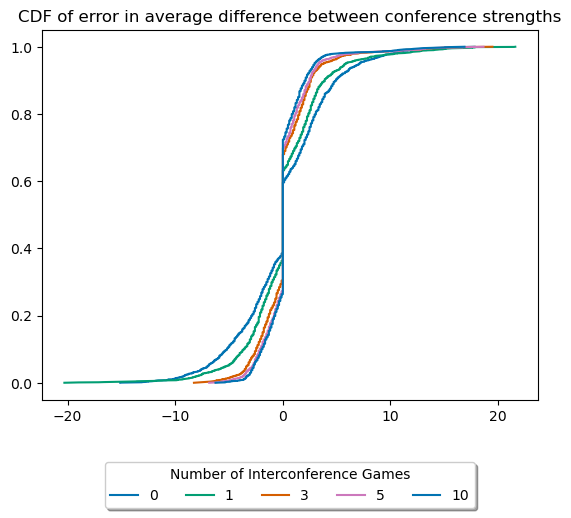

In [196]:
fig = plt.figure
ax = plt.subplot(111)
for i in [0,1,3,5,10]:
    d=pc.difRankDistribution(16,18,i,t=None,reps=2000,comp=True)
    [x,y]=pc.get_ecdf(d)
    plt.plot(x,y,label = i)
ax.set_title("CDF of error in average difference between conference strengths")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
         fancybox=True, shadow=True, ncol=5, title = "Number of Interconference Games")
plt.show()

We can use this emperical distribution to test hypotheses. For instance, based on the 2024 season, is there evidence to suggest that the SEC was significantly better than the Big 10? By power, the SEC had a better average power than the Big 10 by 0.16497. By rank, the SEC was ranked by Zermelo 8.564 spots better than the average Big 10 team. If we compare these difference to the distribution we would expect with the 4 Big 10-SEC matchups that occured in the regular season, we can find the probability of the observed difference given the underlying difference is 0. 

In [197]:
d4=pc.difDistribution(16,18,4,t=None,reps=5000,bias = 0,comp=True)
dr4=pc.difRankDistribution(16,18,4,t=None,reps=5000,bias = 0,comp=True)
[x,y]=pc.get_ecdf(d4)
idx =np.argmax(x>0.16497)
p=y[idx]
print("p-value by power")
print(1-p)
[x,y]=pc.get_ecdf(dr4)
idx =np.argmax(x>-8.564)
p=y[idx]
print("p-value by rank")
print(p)


p-value by power
0.02120424084816963
p-value by rank
0.00020004000800160032


### Part C - Bias persistence in history dependent ranking
Because our results in part A showed that the quality of initial data is so important to the history dependent methods over such a short time frame, we also want to evaluate the ability of the Elo method to remove a systematic bias from initial data under highly modular conditions. The numerical experiment we carry out is described as follows

In a league with two conferences of size 16 and 18 with in which each team plays 9 conference games and there are $M$ interconference games total, we start with an initial ELO ranking which looks like $$ \theta_i=B_i+\frac{1}{c}\ln(\pi)+1500$$ where $B_i$ is the bias indicator which is equal to $b$ when $i\leq n$ and $0$ otherwise. Then we run the ELO algorithm on the synthetic data we get a final ELO and we can investigate how the average ELO differs between conferences given that the average ELO initially was constant between conferences. 

In [ ]:
#df2 = pc.numericalExp2(16,18,0,200,bres = 25,Ms= [0,10,20,40,80], reps = 1000)
#df2.to_csv("DataFiles/NE2.csv")
df2 = pd.read_csv("DataFiles/NE2.csv")

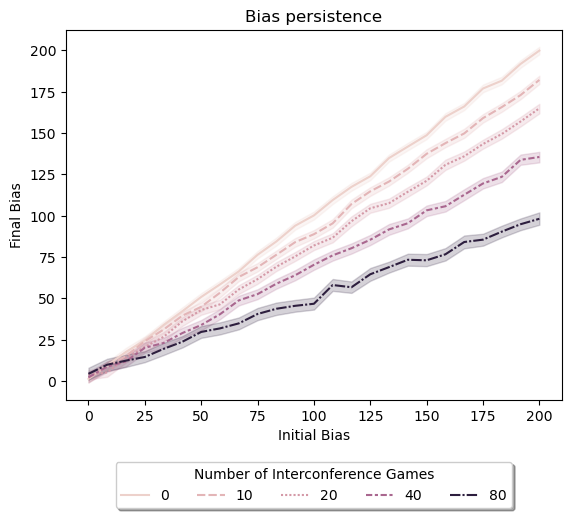

In [199]:
ax = sns.lineplot(data=df2, x='b', y='dif', style = "M", hue = "M")
plt.xlabel('Initial Bias')
plt.ylabel('Final Bias')
plt.title('Bias persistence')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=5, title = "Number of Interconference Games")
plt.show()

These results show that there is no reasonable number of interconference games that can address an initial conference bias sufficiently. Indeed, over the course of a single season of college football, there would need to be 80 total interconference games in order for an initial bias to be reduced by a factor of 1/2.